# Data Cleaning & Preprocessing

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from preprocessing import load_and_clean, get_feature_matrix, prepare_wait_time, prepare_outcome

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

## 1. Raw vs Cleaned Shape

In [2]:
raw = pd.read_csv('../data/ER Wait Time Dataset.csv')
df  = load_and_clean()

print(f'Raw shape:     {raw.shape}')
print(f'Cleaned shape: {df.shape}')
print(f'Columns dropped: {set(raw.columns) - set(df.columns)}')
print(f'Columns added:   {set(df.columns) - set(raw.columns)}')

Raw shape:     (5000, 19)
Cleaned shape: (5000, 13)
Columns dropped: {'Time to Triage (min)', 'Time to Medical Professional (min)', 'Visit ID', 'Hospital Name', 'Patient ID', 'Time to Registration (min)', 'Visit Date', 'Hospital ID'}
Columns added:   {'Hour', 'Is Weekend'}


## 2. Cleaned Data Preview

In [3]:
df.head(10)

,Region,Day of Week,Season,Time of Day,Urgency Level,Nurse-to-Patient Ratio,Specialist Availability,Facility Size (Beds),Total Wait Time (min),Patient Outcome,Patient Satisfaction,Hour,Is Weekend
0,1,6,1,2,2,4,3,92,105,0,1,20,1
1,0,4,4,4,2,4,0,38,69,0,3,2,0
2,0,1,4,4,1,5,1,38,203,0,1,4,0
3,1,2,1,4,3,4,5,94,88,0,2,0,0
4,1,3,2,3,1,4,8,74,118,0,1,16,0
5,1,3,4,5,2,3,7,167,63,0,3,22,0
6,0,3,1,2,2,4,2,42,116,1,1,15,0
7,1,4,1,3,2,3,2,84,81,1,2,20,0
8,1,5,4,3,2,4,3,87,78,0,2,2,0
9,1,6,3,3,4,1,4,99,11,1,5,22,1


In [4]:
df.dtypes

Region                     int64
Day of Week                int64
Season                     int64
Time of Day                int64
Urgency Level              int64
Nurse-to-Patient Ratio     int64
Specialist Availability    int64
Facility Size (Beds)       int64
Total Wait Time (min)      int64
Patient Outcome            int64
Patient Satisfaction       int64
Hour                       int32
Is Weekend                 int64
dtype: object

## 3. Encoding Verification

In [5]:
print('Urgency Level values:', sorted(df['Urgency Level'].unique()))
print('Time of Day values:  ', sorted(df['Time of Day'].unique()))
print('Day of Week values:  ', sorted(df['Day of Week'].unique()))
print('Season values:       ', sorted(df['Season'].unique()))
print('Region values:       ', sorted(df['Region'].unique()))
print('Outcome values:      ', sorted(df['Patient Outcome'].unique()))
print('Is Weekend values:   ', sorted(df['Is Weekend'].unique()))

Urgency Level values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Time of Day values:   [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Day of Week values:   [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Season values:        [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Region values:        [np.int64(0), np.int64(1)]
Outcome values:       [np.int64(0), np.int64(1)]
Is Weekend values:    [np.int64(0), np.int64(1)]


## 4. Feature Matrix

In [6]:
X = get_feature_matrix(df)
print(f'Feature matrix shape: {X.shape}')
print(f'Features: {X.columns.tolist()}')
X.describe().round(2)

Feature matrix shape: (5000, 10)
Features: ['Urgency Level', 'Time of Day', 'Day of Week', 'Season', 'Region', 'Nurse-to-Patient Ratio', 'Specialist Availability', 'Facility Size (Beds)', 'Is Weekend', 'Hour']


,Urgency Level,Time of Day,Day of Week,Season,Region,Nurse-to-Patient Ratio,Specialist Availability,Facility Size (Beds),Is Weekend,Hour
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,2.50,3.21,3.96,2.50,0.60,3.24,3.88,87.12,0.29,11.50
std,1.11,1.12,2.03,1.12,0.49,1.20,3.04,58.00,0.45,6.89
min,1.00,1.00,1.00,1.00,0.00,1.00,0.00,10.00,0.00,0.00
25%,2.00,3.00,2.00,1.00,0.00,3.00,1.00,36.00,0.00,6.00
50%,2.00,3.00,4.00,3.00,1.00,3.00,3.00,74.00,0.00,11.00
75%,3.00,4.00,6.00,3.00,1.00,4.00,6.00,138.00,1.00,18.00
max,4.00,5.00,7.00,4.00,1.00,5.00,10.00,200.00,1.00,23.00


## 5. Train / Test Split Verification

In [7]:
X_train, X_test, y_train, y_test = prepare_wait_time()

print(f'Wait Time model:')
print(f'  Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'  y_train range: {y_train.min():.0f} – {y_train.max():.0f} min')
print()

X_train_o, X_test_o, y_train_o, y_test_o = prepare_outcome()
print(f'Outcome model:')
print(f'  Train: {X_train_o.shape}  |  Test: {X_test_o.shape}')
print(f'  Class balance (train): {y_train_o.value_counts(normalize=True).round(3).to_dict()}')

Wait Time model:
  Train: (4000, 10)  |  Test: (1000, 10)
  y_train range: 4 – 429 min

Outcome model:
  Train: (4000, 10)  |  Test: (1000, 10)
  Class balance (train): {0: 0.626, 1: 0.374}


## 6. Feature Distributions After Encoding

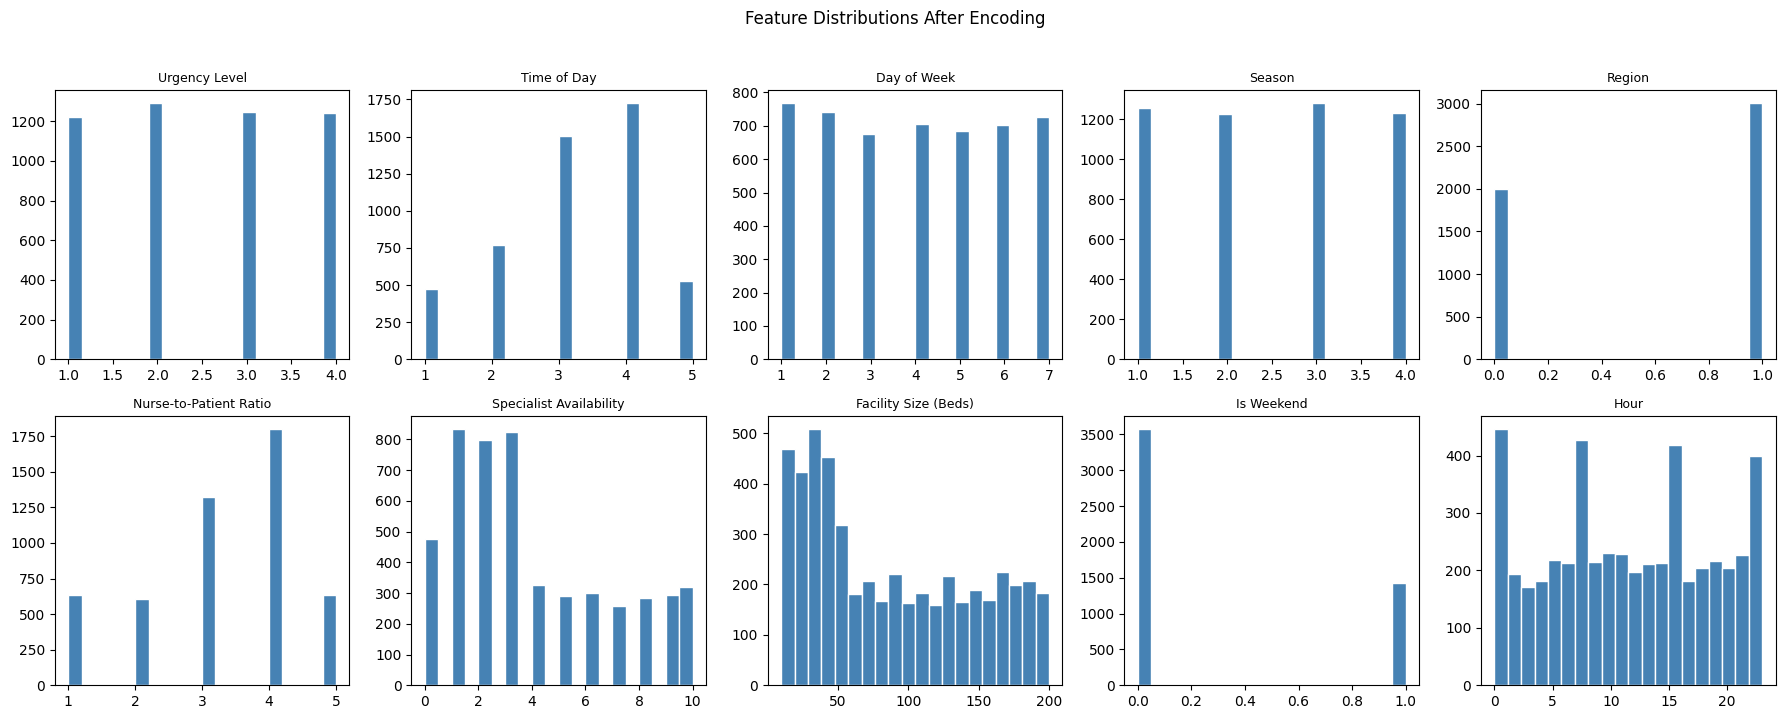

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    axes[i].hist(X[col], bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=9)

for j in range(len(X.columns), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions After Encoding', y=1.02)
plt.tight_layout()
plt.show()

## 7. Feature Correlation with Target

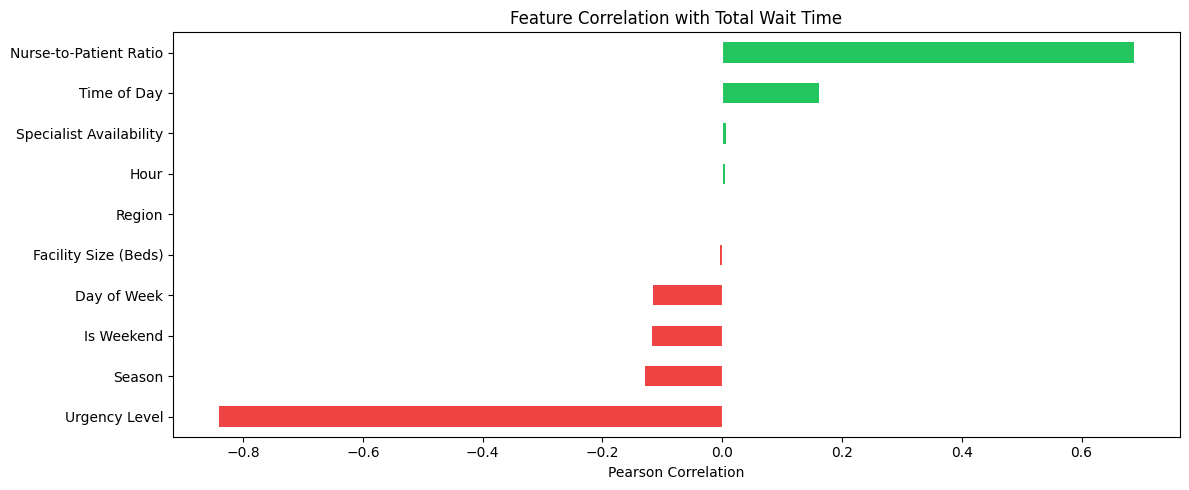

Urgency Level             -0.841
Season                    -0.129
Is Weekend                -0.117
Day of Week               -0.116
Facility Size (Beds)      -0.004
Region                     0.001
Hour                       0.005
Specialist Availability    0.007
Time of Day                0.162
Nurse-to-Patient Ratio     0.688
dtype: float64


In [9]:
corr_with_target = X.corrwith(df['Total Wait Time (min)']).sort_values()

colors = ['#ef4444' if v < 0 else '#22c55e' for v in corr_with_target.values]
corr_with_target.plot(kind='barh', color=colors)
plt.axvline(0, color='white', linewidth=0.8)
plt.title('Feature Correlation with Total Wait Time')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

print(corr_with_target.round(3))